Dataset Shape: 180 rows, 17 columns

Data Types & Summary Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Flight_ID               180 non-null    object 
 1   Flight_Date             180 non-null    object 
 2   Airline                 180 non-null    object 
 3   Origin                  180 non-null    object 
 4   Destination             180 non-null    object 
 5   Aircraft                180 non-null    object 
 6   Travel_Class            180 non-null    object 
 7   Passengers              180 non-null    int64  
 8   Seat_Capacity           180 non-null    int64  
 9   Average_Ticket_Price    180 non-null    int64  
 10  Delay_Minutes           173 non-null    float64
 11  Flight_Status           180 non-null    object 
 12  Weather                 180 non-null    object 
 13  Booking_Channel         180 non

,Flight_ID,Flight_Date,Airline,Origin,Destination,Aircraft,Travel_Class,Passengers,Seat_Capacity,Average_Ticket_Price,Delay_Minutes,Flight_Status,Weather,Booking_Channel,Avg_Baggage_Kg,Meal_Preference,Passenger_Satisfaction
0,FL0001,2026-03-23,SpiceJet,Mumbai,Bengaluru,Airbus A319,Economy,210,180,6894,50.0,Delayed,Storm,Online Travel Portal,23,No Meal,3
1,FL0002,2026-06-07,Akasa Air,Delhi,Mumbai,Boeing 737,Economy,70,210,4468,0.0,On Time,Fog,Travel Agency,16,Vegan,5
2,FL0003,2026-05-12,Air India,Kochi,Delhi,Boeing 737,Economy,67,220,4713,5.0,On Time,Rain,Travel Agency,19,No Meal,2
3,FL0004,2026-05-30,Akasa Air,Srinagar,Delhi,Airbus A319,Economy,153,220,3791,35.0,Delayed,Storm,Travel Agency,18,No Meal,2
4,FL0005,2026-02-27,Air India,Pune,Delhi,Airbus A319,Premium Economy,178,180,6505,20.0,Delayed,Cloudy,Airline Website,25,No Meal,5


Missing values per column:
Delay_Minutes    7
dtype: int64

Duplicate Rows: 0


,Flight_ID,Passengers,Seat_Capacity,Occupancy_Rate,Total_Revenue
0,FL0001,210,180,116.666667,1447740
1,FL0002,70,210,33.333333,312760
2,FL0003,67,220,30.454545,315771
3,FL0004,153,220,69.545455,580023
4,FL0005,178,180,98.888889,1157890


Number of flights generating > 1M Revenue: 38

Top 5 Most Delayed Flights:


,Flight_ID,Airline,Origin,Destination,Delay_Minutes,Weather
50,FL0051,Air India,Delhi,Mumbai,110.0,Rain
26,FL0027,SpiceJet,Bengaluru,Hyderabad,110.0,Clear
82,FL0083,Air India Express,Lucknow,Delhi,110.0,Cloudy
57,FL0058,IndiGo,Hyderabad,Kolkata,110.0,Cloudy
177,FL0178,IndiGo,Delhi,Mumbai,110.0,Fog


,Airline,Total_Flights,Total_Passengers,Total_Revenue,Avg_Delay_Min,Avg_Satisfaction,Avg_Occupancy_Pct
5,Vistara,37,4484,28689467,17.891892,3.378378,61.868716
3,IndiGo,32,4158,25709131,25.031250,3.343750,66.778509
4,SpiceJet,32,3929,24195935,22.343750,3.531250,63.604102
1,Air India Express,24,3027,23944164,11.291667,3.666667,64.786071
2,Akasa Air,31,3427,18872059,14.096774,3.419355,55.212934
0,Air India,24,3074,16232418,20.583333,3.750000,64.655403


,Travel_Class,Total_Revenue,Avg_Ticket_Price,Avg_Satisfaction
0,Business,24318965,16780.000000,3.272727
1,Economy,73536524,4550.268657,3.462687
2,Premium Economy,39787685,8736.742857,3.685714


/tmp/ipykernel_1412/918246867.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=airline_summary, x='Airline', y='Total_Revenue', ax=axes[0,0], palette='Blues_d')
/tmp/ipykernel_1412/918246867.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=airline_summary, x='Airline', y='Avg_Delay_Min', ax=axes[0,1], palette='Reds_d')


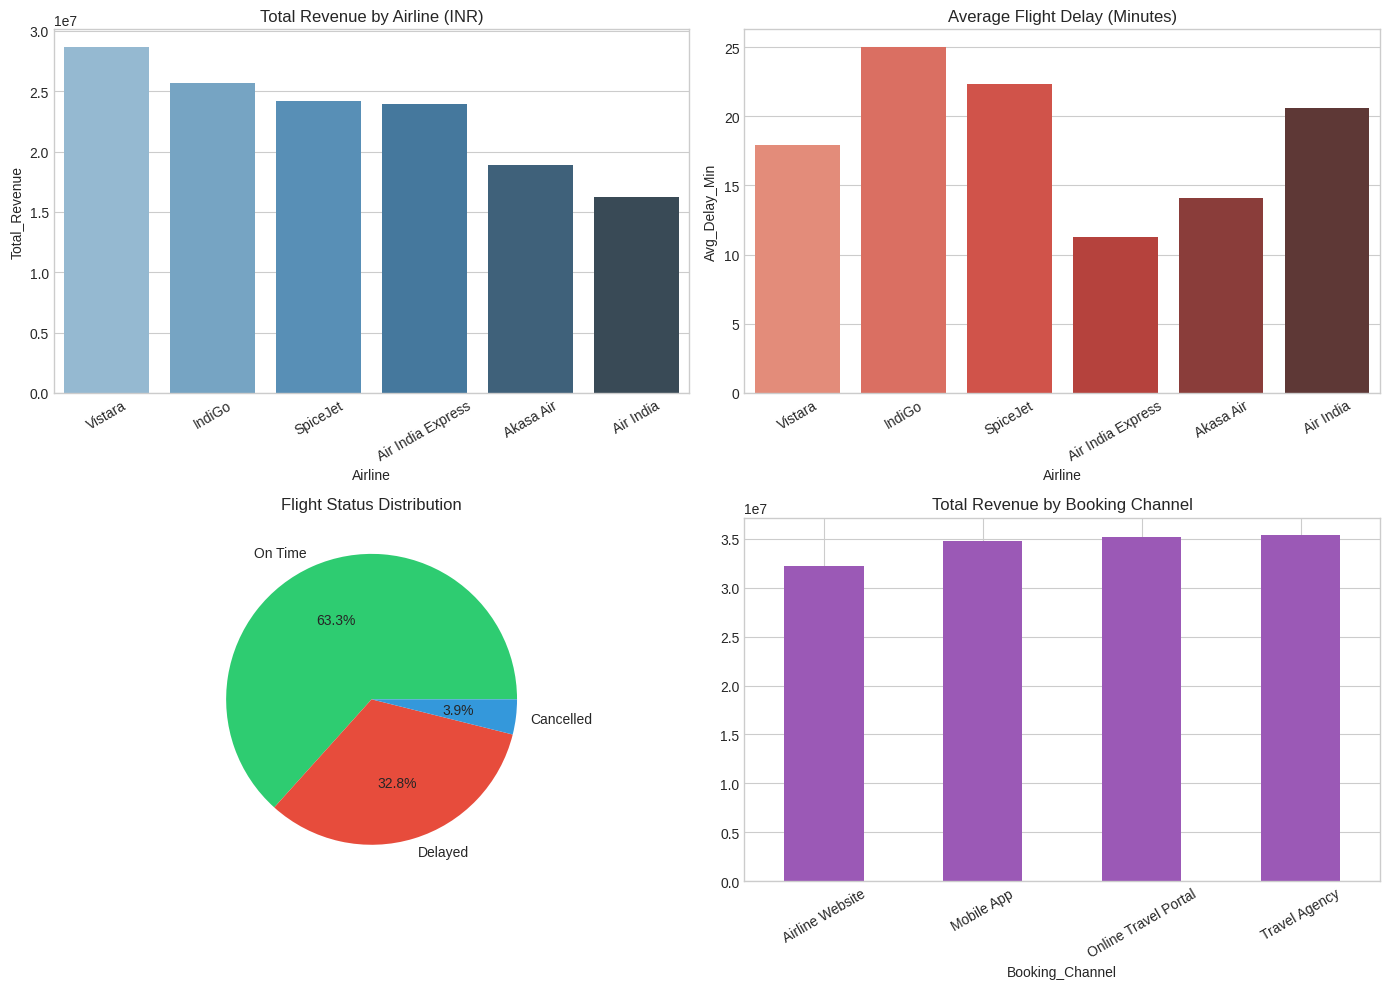

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)

df = pd.read_csv('Day10_Flight_Operations_Dataset.csv')

print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
print("Data Types & Summary Info:")
df.info()

print("\nFirst 5 Rows:")
display(df.head())

print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])

print(f"\nDuplicate Rows: {df.duplicated().sum()}")

df['Delay_Minutes'] = df['Delay_Minutes'].fillna(df['Delay_Minutes'].median())

df['Flight_Date'] = pd.to_datetime(df['Flight_Date'])

df['Total_Revenue'] = df['Passengers'] * df['Average_Ticket_Price']

df['Occupancy_Rate'] = (df['Passengers'] / df['Seat_Capacity']) * 100

df['Month'] = df['Flight_Date'].dt.month_name()

display(df[['Flight_ID', 'Passengers', 'Seat_Capacity', 'Occupancy_Rate', 'Total_Revenue']].head())

high_rev_flights = df[df['Total_Revenue'] > 1000000]
print(f"Number of flights generating > 1M Revenue: {len(high_rev_flights)}")

top_delayed = df.sort_values(by='Delay_Minutes', ascending=False).head(5)
print("\nTop 5 Most Delayed Flights:")
display(top_delayed[['Flight_ID', 'Airline', 'Origin', 'Destination', 'Delay_Minutes', 'Weather']])

airline_summary = df.groupby('Airline').agg(
    Total_Flights=('Flight_ID', 'count'),
    Total_Passengers=('Passengers', 'sum'),
    Total_Revenue=('Total_Revenue', 'sum'),
    Avg_Delay_Min=('Delay_Minutes', 'mean'),
    Avg_Satisfaction=('Passenger_Satisfaction', 'mean'),
    Avg_Occupancy_Pct=('Occupancy_Rate', 'mean')
).reset_index().sort_values(by='Total_Revenue', ascending=False)

display(airline_summary)

class_summary = df.groupby('Travel_Class').agg(
    Total_Revenue=('Total_Revenue', 'sum'),
    Avg_Ticket_Price=('Average_Ticket_Price', 'mean'),
    Avg_Satisfaction=('Passenger_Satisfaction', 'mean')
).reset_index()

display(class_summary)


fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.barplot(data=airline_summary, x='Airline', y='Total_Revenue', ax=axes[0,0], palette='Blues_d')
axes[0,0].set_title('Total Revenue by Airline (INR)')
axes[0,0].tick_params(axis='x', rotation=30)

sns.barplot(data=airline_summary, x='Airline', y='Avg_Delay_Min', ax=axes[0,1], palette='Reds_d')
axes[0,1].set_title('Average Flight Delay (Minutes)')
axes[0,1].tick_params(axis='x', rotation=30)

df['Flight_Status'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[1,0], colors=['#2ecc71', '#e74c3c', '#3498db'])
axes[1,0].set_title('Flight Status Distribution')
axes[1,0].set_ylabel('')

df.groupby('Booking_Channel')['Total_Revenue'].sum().plot(kind='bar', ax=axes[1,1], color='#9b59b6')
axes[1,1].set_title('Total Revenue by Booking Channel')
axes[1,1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()